# Traitement de signaux bruités

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import matplotlib.pyplot as plt
plt.style.use('../signal.mplstyle')

In [2]:
def myplot(x, y, name, title, ylim, ax):
    
    for side in ['bottom', 'top', 'right', 'left']:
        ax.spines[side].set_color('k')
        ax.spines[side].set_linewidth(0.5)
    ax.grid(linewidth=0.5)
    
    ax.set_xlim( [-200,  200] if name[0]=="R" else [   0, 200] )
    ax.set_ylim( ylim if name[0]=="R" else [-2.5, 2.5] )
    
    plt.plot(x, y, 'tab:blue')

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(title, fontsize=16)

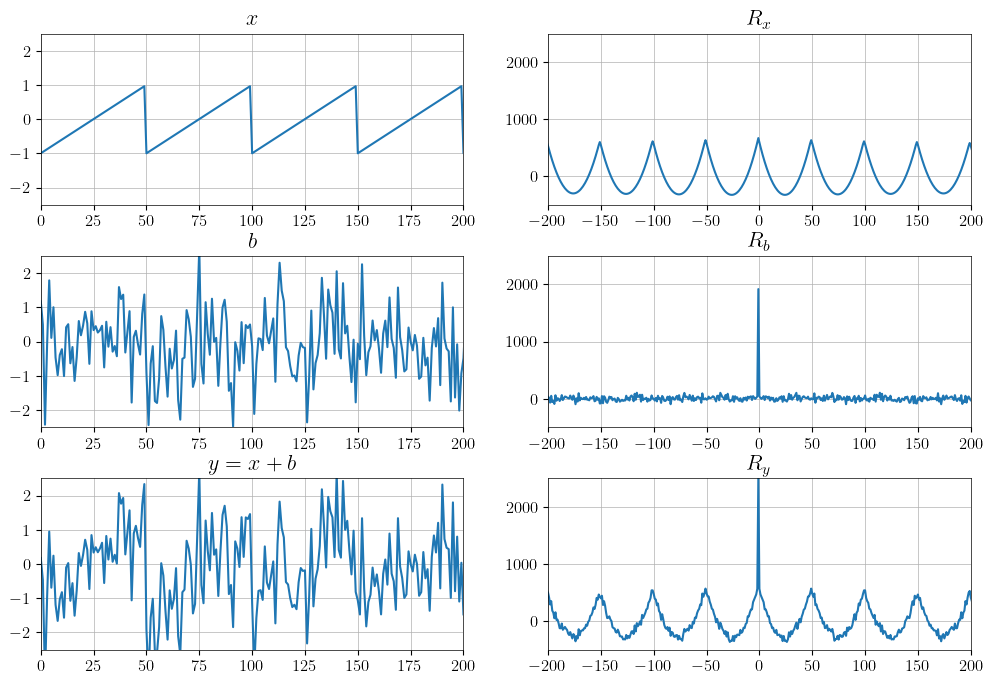

In [3]:
# Détection d'un signal périodique de période inconnue

N = 2000
n = np.arange(N)
m = np.arange(-N, N-1)

# Signal non bruité
x = signal.sawtooth(2*np.pi*n*0.02)
Rx = np.correlate(x, x, "full")

# Bruit
b = np.random.normal(0, 1, N)
Rb = np.correlate(b, b, "full")

# Signal bruité
y = x + b
Ry = np.correlate(y, y, "full")

# Affichage
fig = plt.figure(figsize=(12, 8))
ax = plt.subplot(3,2,1)
myplot(n, x, "x", "$x$", [], ax)
ax = plt.subplot(3,2,2)
myplot(m, Rx, "Rx", "$R_x$", [-500, 2500], ax)
ax = plt.subplot(3,2,3)
myplot(n, b, "b", "$b$", [], ax)
ax = plt.subplot(3,2,4)
myplot(m, Rb, "Rb", "$R_b$", [-500, 2500], ax)
ax = plt.subplot(3,2,5)
myplot(n, y, "y", "$y=x+b$", [], ax)
ax = plt.subplot(3,2,6)
myplot(m, Ry, "Ry", "$R_y$", [-500, 2500], ax)
plt.subplots_adjust(hspace=0.3)
plt.savefig("detection1.svg")

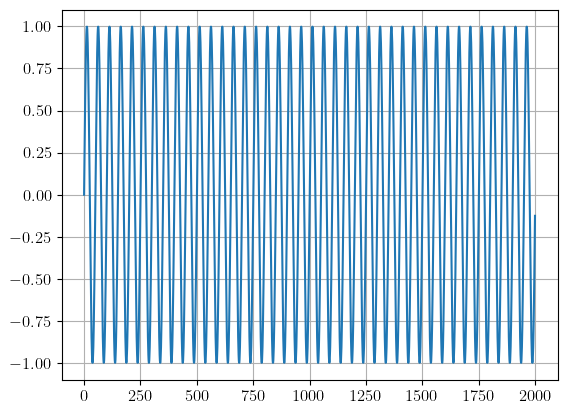

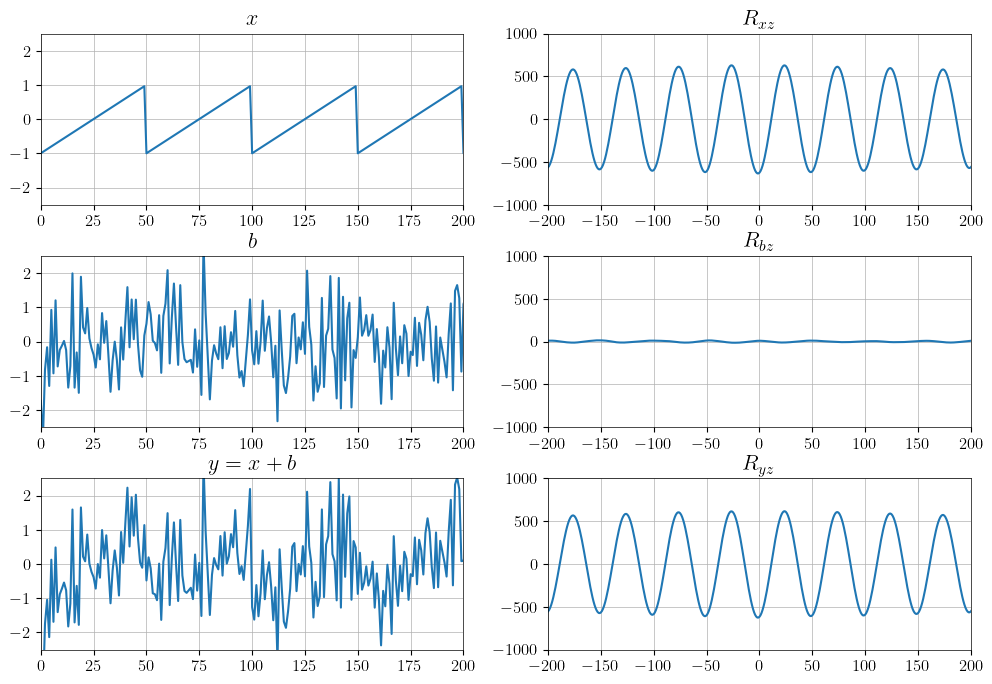

In [4]:
# Détection d'un signal périodique de période connue

N = 2000
n = np.arange(N)
m = np.arange(-N, N-1)

# Signal non bruité
x = signal.sawtooth(2*np.pi*n*0.02)

# Signal auxiliaire
z = np.sin(2*np.pi*n*0.02)
plt.figure
plt.plot(n,z)

# Bruit
b = np.random.normal(0, 1, N)

# Signal bruité
y = x + b

# Intercorrélations
Rxz = np.correlate(x, z, "full")
Rbz = np.correlate(b, z, "full")
Ryz = np.correlate(y, z, "full")

# Affichage
fig = plt.figure(figsize=(12, 8))
ax = plt.subplot(3,2,1)
myplot(n, x, "x", "$x$", [], ax)
ax = plt.subplot(3,2,2)
myplot(m, Rxz, "Rxz", "$R_{xz}$", [-1000, 1000], ax)
ax = plt.subplot(3,2,3)
myplot(n, b, "b", "$b$", [], ax)
ax = plt.subplot(3,2,4)
myplot(m, Rbz, "Rbz", "$R_{bz}$", [-1000, 1000], ax)
ax = plt.subplot(3,2,5)
myplot(n, y, "y", "$y=x+b$", [], ax)
ax = plt.subplot(3,2,6)
myplot(m, Ryz, "Ryz", "$R_{yz}$", [-1000, 1000], ax)
plt.subplots_adjust(hspace=0.3)
plt.savefig("detection2.svg")

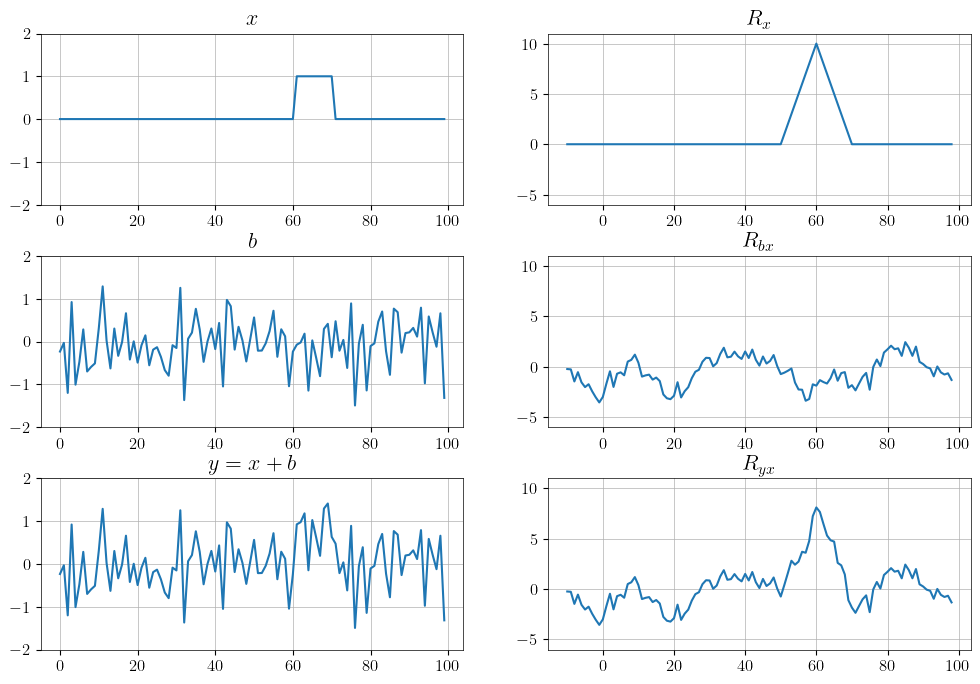

In [5]:
# Exemple de filtre adapté

def addplot(x, y, title, ylim):
    
    # Nouveau subplot
    spi = len(fig.get_axes()) + 1
    ax = plt.subplot(3, 2, spi)
    
    # Bordure en noir + grille
    for side in ['bottom', 'top', 'right', 'left']:
        ax.spines[side].set_color('k')
        ax.spines[side].set_linewidth(0.5)
    ax.grid(linewidth=0.5)
    
    # Signal
    plt.plot(x, y, 'tab:blue')
    ax.set_ylim(ylim)
    
    # Taille de police
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(title, fontsize=16)


np.random.seed(2)

N = 100
# nx = np.arange(-N/2, N/2)
n = np.arange(0, N)
# mx = np.arange(-N, N-1)
M = N+10-1
m = np.arange(-10, N-1)

# Motif
h = np.ones(10)

# Motif décalé
x = np.concatenate([np.zeros(61), h, np.zeros(29)])

# Bruit
rsb = 15
Px = np.linalg.norm(x)**2
sig = np.sqrt( Px * 10**(-rsb/10) )
b = np.random.randn(N)*sig

# Observation
y = x + b

# Intercorrélations
Rxx = np.correlate(x, h, "full")
Rbx = np.correlate(b, h, "full")
Ryx = np.correlate(y, h, "full")

# Affichage
fig = plt.figure(figsize=(12, 8))
addplot(n, x,   "$x$",       ylim=[-2, 2])
addplot(m, Rxx, "$R_{x}$",   ylim=[-6, 11])
addplot(n,  b,   "$b$",      ylim=[-2, 2])
addplot(m,  Rbx, "$R_{bx}$", ylim=[-6, 11])
addplot(n,  y,   "$y=x+b$",  ylim=[-2, 2])
addplot(m,  Ryx, "$R_{yx}$", ylim=[-6, 11])
plt.subplots_adjust(hspace=0.3)
plt.savefig("filtre-adapte.svg")

[ 4  9  8  7 12  5  1  0  5  4  3  2  4]
[7. 8. 9. 8. 6. 2. 2. 3. 4. 3. 3.]


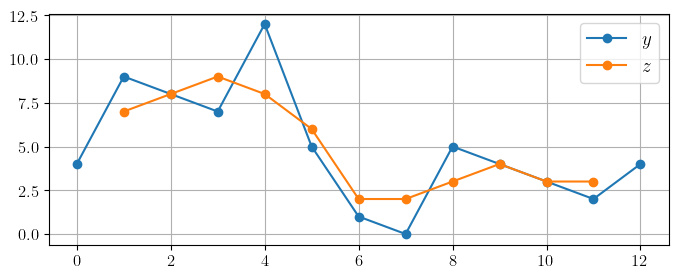

In [6]:
# Données
y = np.array([4, 9, 8, 7, 12, 5, 1, 0, 5, 4, 3, 2, 4])
M = len(y)
m = np.arange(M)

# Filtre moyenneur
N = 3
h = np.ones(N)/N
z = np.convolve(y, h, mode="valid")

print(y)
print(z)

fig = plt.figure(figsize=(8,3))
plt.plot(m, y, "o-", label="$y$")
plt.plot(m[1:-1], z, "o-", label="$z$")
plt.legend()
plt.savefig("filtre-moyenneur-exemple.svg")

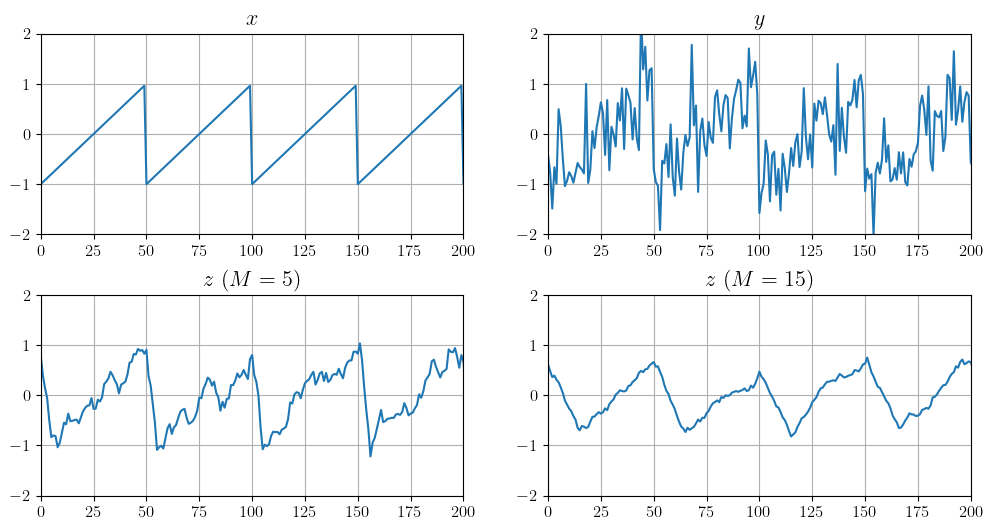

In [7]:
# Filtre moyenneur

def addplot(x, y, title):
    
    # Nouveau subplot
    spi = len(fig.get_axes()) + 1
    ax = plt.subplot(2, 2, spi)
    
#     # Bordure en noir + grille
#     for side in ['bottom', 'top', 'right', 'left']:
#         ax.spines[side].set_color('k')
#         ax.spines[side].set_linewidth(0.5)
#     ax.grid(linewidth=0.5)
    
    # Signal
    plt.plot(x, y, 'tab:blue')
    ax.set_xlim([0, 200])
    ax.set_ylim([-2, 2])
    
    # Taille de police
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(title, fontsize=16)

    
# Signal bruité
N = 2000
n = np.arange(0, N)
x = signal.sawtooth(2*np.pi*n*0.02)
b = np.random.normal(0, 0.5, N)
y = x + b

# Affichage
fig = plt.figure(figsize=(12, 6))
addplot(n, x, "$x$")
addplot(n, y, "$y$")

# Application du filtre moyenneur
for M in [5, 15]:
    
    # Réponse impulsionnelle
    h = np.concatenate([np.ones(M), np.zeros(N-M)]) / M
    
    # Signal débruité
    z = np.convolve(y, h, 'same')
    
    # Affichage
    addplot(n, z, f"$z$ ($M={M}$)")

plt.subplots_adjust(hspace=0.3)
plt.savefig("filtre-moyenneur.svg")

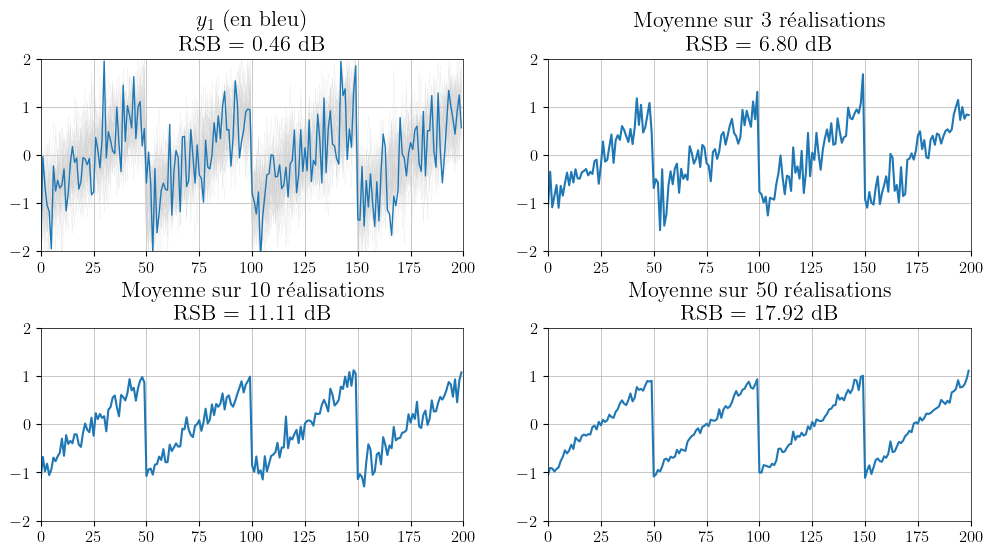

In [8]:
# Moyennage de plusieurs signaux

def addplot(x, y, rsb, title):
    
    # Nouveau subplot
    spi = len(fig.get_axes()) + 1
    ax = plt.subplot(2, 2, spi)
    
    # Bordure en noir + grille
    for side in ['bottom', 'top', 'right', 'left']:
        ax.spines[side].set_color('k')
        ax.spines[side].set_linewidth(0.5)
    ax.grid(linewidth=0.5)
    
    # Signal
    if spi==1:
        for k in range(1,y.shape[0]):
            plt.plot(x, y[k,:], 'lightgray', linewidth=0.1)
        plt.plot(x, y[0,:], 'tab:blue', linewidth=1)
    else:
        plt.plot(x, y, 'tab:blue')
    ax.set_xlim([0, 200])
    ax.set_ylim([-2, 2])
    
    # Taille de police
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(title + '\nRSB = {:.2f} dB'.format(rsb), fontsize=16)

# K signaux bruités
K = 50
N = 200
n = np.arange(0, N)
# x = np.sin(2*np.pi*n*0.02)
x = signal.sawtooth(2*np.pi*n*0.02)
Px = np.linalg.norm(x)**2/N
y = np.zeros((K,N))
for k in range(K):
    yk = x + np.random.normal(0, 0.5, N)
    y[k,:] = yk
    
# RSB
b = y[0,:] - x
Pb = np.linalg.norm(b)**2/N
rsb = 10 * np.log10(Px/Pb)

# Affichage
fig = plt.figure(figsize=(12, 6))
addplot(n, y, rsb, "$y_1$ (en bleu)")

# Moyennage
for L in [3, 10, 50]:
    
    # Moyennage
    z = np.mean(y[0:L,:], axis=0)
    
    # RSB
    b = z - x
    Pb = np.linalg.norm(b)**2/N
    rsb = 10 * np.log10(Px/Pb)
    
    # Affichage
    addplot(n, z, rsb, f"Moyenne sur {L} réalisations")

plt.subplots_adjust(hspace=0.4)
plt.savefig("moyennage.svg")

## Moindres carrés

In [9]:
# Approximation par moindres carrés

# Polynôme bruité
N = 201
n = np.linspace(-1, 1, N)
x = 2 + 5*n - 3*n**2 - 2*n**3
b = np.random.normal(0, 1, N)
y = x + b
# myplot(n, x, '$x$', 'x')

# Filtre moyenneur
M = 20
L = (int)((N/M)/2)
h = np.concatenate([ np.zeros(L), np.ones(M), np.zeros(L)]) / M
z = np.convolve(y, h, 'same')

# Moindres carrés
H = np.vstack([ n**0, n*1, n**2, n**2 ]).T
c = np.linalg.lstsq(H, y, rcond=None)[0]
w = np.dot(H,c)

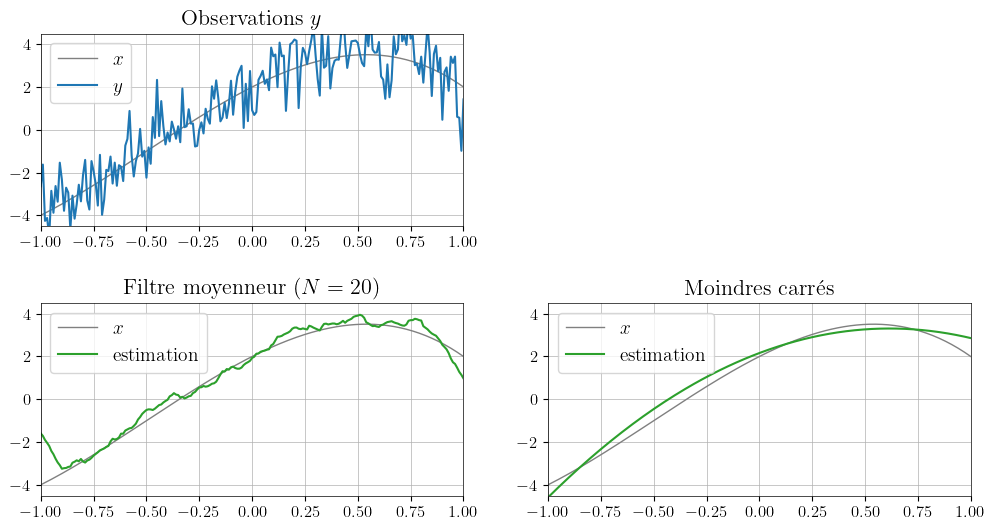

In [10]:
def addplot(x, y, gt, title):
    
    # Nouveau subplot
    if len(fig.get_axes())==0:
        spi = 1
    else:
        spi = len(fig.get_axes()) + 2
    ax = plt.subplot(2, 2, spi)
    
    # Bordure en noir + grille
    for side in ['bottom', 'top', 'right', 'left']:
        ax.spines[side].set_color('k')
        ax.spines[side].set_linewidth(0.5)
    ax.grid(linewidth=0.5)
    
    # Signal
    plt.plot(x, gt, 'gray', linewidth=1, label="$x$")
    plt.plot(x, y, 'tab:blue' if spi==1 else 'tab:green',
            label='$y$' if spi==1 else 'estimation')
    ax.set_xlim([-1, 1])
    ax.set_ylim([-4.5, 4.5])
    
    # Taille de police
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(title, fontsize=16)
    plt.legend()

# Affichage
fig = plt.figure(figsize=(12, 6))
addplot(n, y, x, 'Observations $y$')
addplot(n, z, x, 'Filtre moyenneur ($N=' + str(M) + '$)')
addplot(n, w, x, 'Moindres carrés')
plt.subplots_adjust(hspace=0.4)
plt.savefig("moindres-carres.svg")

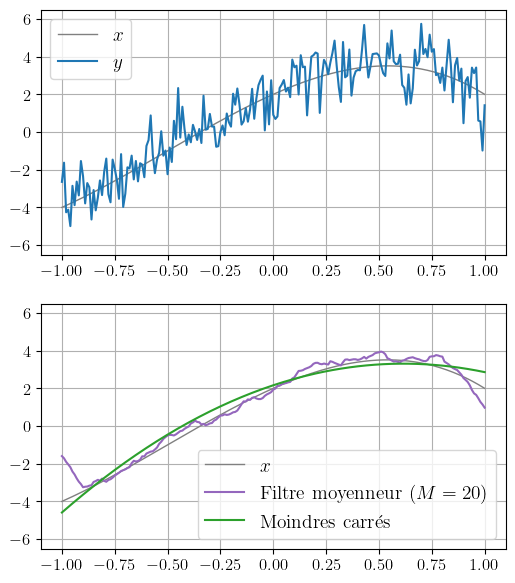

In [15]:
# Affichage des estimations

fig, axs = plt.subplots(2, 1, figsize=(6, 7))
    
axs[0].plot(n, x, 'gray', linewidth=1, label="$x$")
axs[0].plot(n, y, 'tab:blue', label='$y$')
axs[0].set_ylim([-6.5, 6.5])
axs[0].legend()
    
axs[1].plot(n, x, 'gray', linewidth=1, label="$x$")
axs[1].plot(n, z, 'tab:purple', label='Filtre moyenneur ($M=' + str(M) + '$)')
axs[1].plot(n, w, 'tab:green', label='Moindres carrés')
axs[1].set_ylim([-6.5, 6.5])
axs[1].legend()

plt.savefig("moindres-carres.svg")

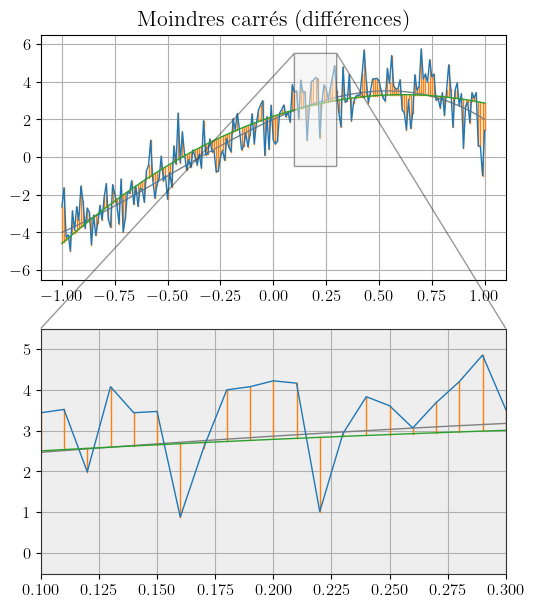

In [16]:
# Affichage des différences

fig, axs = plt.subplots(2, 1, figsize=(6, 7))

# Coordonnées du zoom
xmin, xmax = 110, 130

# Zoom
zoom_face_color = "#eee"
zoom_edge_color = "#333"
axs[0].indicate_inset_zoom(axs[1], facecolor=zoom_face_color, edgecolor=zoom_edge_color)
axs[1].set_facecolor(zoom_face_color)
for spine in ['top', 'bottom', 'left', 'right']:
    axs[1].spines[spine].set_color(zoom_edge_color)

# Signaux
for i in range(2):
    axs[i].plot([n,n], [w,y], 'tab:orange', linewidth=1)
    axs[i].plot(n, x, 'gray',      linewidth=1)
    axs[i].plot(n, y, 'tab:blue',  linewidth=1)
    axs[i].plot(n, w, 'tab:green', linewidth=1)

# Axes
axs[0].set_ylim([-6.5, 6.5])
axs[1].set_xlim([n[xmin], n[xmax]])
axs[1].set_ylim([-0.5, 5.5])

# Titre
axs[0].set_title("Moindres carrés (différences)", fontsize=16)

# Enregistrement
plt.savefig("moindres-carres-differences.svg")